Import e percorsi

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"


# Manifest prodotto dal notebook 01:
# contiene solo le classi selezionate per l'esperimento Siamese
# e il training set già sottoposto a downsampling.

MANIFEST_PATH = (
    PROCESSED_DIR
    / "siamese_primary_manifest.tsv"
)


# FASTA originale contenente le sequenze

FASTA_PATH = (
    RAW_DIR
    / "eccdna_disease_detection.body.fa"
)


print(
    "Manifest:",
    MANIFEST_PATH.exists(),
    MANIFEST_PATH
)

print(
    "FASTA:",
    FASTA_PATH.exists(),
    FASTA_PATH
)

Manifest: True ..\data\processed\siamese_primary_manifest.tsv
FASTA: True ..\data\raw\eccdna_disease_detection.body.fa


Caricamento metadata

In [11]:
metadata = pd.read_csv(
    MANIFEST_PATH,
    sep="\t",
    low_memory=False
)


print(
    "Shape manifest:",
    metadata.shape
)

print(
    "Numero classi:",
    metadata["disease_clean"].nunique()
)

print(
    "ID unici:",
    metadata["id"].nunique()
)

print(
    "Duplicati:",
    metadata["id"].duplicated().sum()
)


display(
    metadata[
        [
            "id",
            "disease",
            "disease_clean",
            "disease_group",
            "class_id",
            "length",
            "gc",
            "n_fraction",
            "source_db",
            "split_cluster",
        ]
    ].head()
)

Shape manifest: (665681, 12)
Numero classi: 18
ID unici: 665681
Duplicati: 0


,id,disease,disease_clean,disease_group,class_id,length,gc,n_fraction,source_db,split_cluster
0,CircleBaseV2_000726522,Gastric cancer,gastric cancer,cancer,0,1726,0.335458,0.0,CircleBaseV2,train
1,CircleBaseV2_000119689,Gastric cancer,gastric cancer,cancer,0,1502,0.448069,0.0,CircleBaseV2,train
2,CircleBaseV2_002112184,Gastric cancer,gastric cancer,cancer,0,6595,0.370129,0.0,CircleBaseV2,train
3,CircleBaseV2_001452203,Gastric cancer,gastric cancer,cancer,0,1431,0.343117,0.0,CircleBaseV2,train
4,CircleBaseV2_000827693,Gastric cancer,gastric cancer,cancer,0,2421,0.397356,0.0,CircleBaseV2,train


In [12]:
class_distribution = pd.crosstab(
    metadata["disease_clean"],
    metadata["split_cluster"]
)

class_distribution = (
    class_distribution
    .sort_values(
        "train",
        ascending=False
    )
)

class_distribution

split_cluster,test,train,val
disease_clean,,,
colorectal cancer,4422,10000,8511
cervical adenocarcinoma,1958,10000,3719
ovarian cancer,8355,10000,16767
prostate cancer,8263,10000,16224
healthy,20852,10000,43143
gastric cancer,128668,10000,252571
hiv infectious disease,2157,10000,4158
lymphoma,3409,10000,6776
leukemia,1138,10000,2318


# Pilot tecnico per la validazione della FCGR

Prima di eseguire un'analisi più estesa viene costruito un piccolo pilot
contenente campioni appartenenti a tutte le classi dell'esperimento.

Il pilot viene estratto esclusivamente dal **training set**.

Validation e test non vengono utilizzati per la scelta dei parametri della
rappresentazione FCGR, in modo da evitare che informazioni provenienti dagli
insiemi di valutazione influenzino la scelta di `k`.

Questo primo pilot serve solamente a verificare:

- corretta lettura delle sequenze dal FASTA;
- corrispondenza tra ID e sequenza;
- corretta generazione delle FCGR;
- normalizzazione delle matrici;
- comportamento della rappresentazione per valori di `k` compresi tra 4 e 10.

In [13]:
# ============================================================
# TRAINING SET
# ============================================================

train_metadata = metadata[
    metadata["split_cluster"] == "train"
].copy()


# ============================================================
# CLASSI DEL PILOT
# ============================================================

# Recuperiamo automaticamente le classi dal manifest,
# rispettando l'ordine dei class_id definiti nel notebook 01.

class_mapping = (
    metadata[
        [
            "disease_clean",
            "class_id"
        ]
    ]
    .drop_duplicates()
    .sort_values("class_id")
)


PILOT_CLASSES = (
    class_mapping["disease_clean"]
    .tolist()
)


N_PER_CLASS = 5
RANDOM_STATE = 42


print(
    "Campioni training:",
    f"{len(train_metadata):,}"
)

print(
    "Classi nel pilot:",
    len(PILOT_CLASSES)
)

display(class_mapping)

Campioni training: 126,265
Classi nel pilot: 18


,disease_clean,class_id
0,gastric cancer,0
10000,healthy,1
20000,ovarian cancer,2
30000,prostate cancer,3
40000,colorectal cancer,4
50000,lymphoma,5
60000,hiv infectious disease,6
70000,cervical adenocarcinoma,7
80000,leukemia,8
90000,primary pulmonary hypertension,9


In [14]:
pilot_parts = []


for class_idx, disease in enumerate(
    PILOT_CLASSES
):

    subset = train_metadata[
        train_metadata[
            "disease_clean"
        ] == disease
    ]


    sampled = subset.sample(
        n=min(
            N_PER_CLASS,
            len(subset)
        ),
        replace=False,
        random_state=(
            RANDOM_STATE
            + class_idx
        )
    )


    pilot_parts.append(
        sampled
    )


pilot_metadata = pd.concat(
    pilot_parts,
    ignore_index=True
)


print(
    "Numero sequenze pilot:",
    len(pilot_metadata)
)


display(
    pd.crosstab(
        pilot_metadata[
            "disease_clean"
        ],
        pilot_metadata[
            "split_cluster"
        ]
    )
)


display(
    pilot_metadata[
        [
            "id",
            "disease_clean",
            "class_id",
            "length",
            "gc",
            "source_db"
        ]
    ]
)

Numero sequenze pilot: 90


split_cluster,train
disease_clean,
branchio-oculo-facial syndrome (bofs),5
cataract,5
cervical adenocarcinoma,5
chronic kidney disease,5
colorectal cancer,5
dilated cardiomyopathy,5
gastric cancer,5
glioblastoma cancer,5
healthy,5


,id,disease_clean,class_id,length,gc,source_db
0,CircleBaseV2_001148946,gastric cancer,0,411,0.481752,CircleBaseV2
1,CircleBaseV2_002170938,gastric cancer,0,2684,0.374441,CircleBaseV2
2,CircleBaseV2_000639173,gastric cancer,0,566,0.397527,CircleBaseV2
3,CircleBaseV2_000822283,gastric cancer,0,983,0.418108,CircleBaseV2
4,CircleBaseV2_001903047,gastric cancer,0,745,0.401342,CircleBaseV2
...,...,...,...,...,...,...
85,eccDNABase_000571176,branchio-oculo-facial syndrome (bofs),17,425,0.517647,eccDNABase
86,eccDNABase_000569526,branchio-oculo-facial syndrome (bofs),17,849,0.415783,eccDNABase
87,eccDNABase_000569185,branchio-oculo-facial syndrome (bofs),17,1162,0.409639,eccDNABase
88,eccDNABase_000569446,branchio-oculo-facial syndrome (bofs),17,204,0.426471,eccDNABase


# Recupero delle sequenze dal FASTA

Il file FASTA contiene le sequenze nucleotidiche associate agli identificativi presenti nel metadata.

Per il pilot dataset vengono recuperate esclusivamente le sequenze necessarie, evitando di caricare l'intero FASTA in memoria.

In [15]:
def load_fasta_sequences(
    fasta_path,
    target_ids
):
    """
    Recupera dal FASTA solamente le sequenze
    i cui ID sono presenti in target_ids.

    L'ID FASTA viene interpretato come la parte
    dell'header precedente al primo carattere "|".
    """

    target_ids = set(
        map(str, target_ids)
    )

    sequences = {}

    current_id = None
    current_sequence = []
    current_is_target = False


    with open(
        fasta_path,
        "r"
    ) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue


            if line.startswith(">"):

                # Salvataggio del record precedente
                if (
                    current_id is not None
                    and current_is_target
                ):

                    sequences[current_id] = (
                        "".join(
                            current_sequence
                        )
                    )

                    # Tutte le sequenze richieste
                    # sono state trovate
                    if (
                        len(sequences)
                        == len(target_ids)
                    ):
                        break


                header = line[1:]

                current_id = (
                    header
                    .split("|", 1)[0]
                    .strip()
                )

                current_is_target = (
                    current_id
                    in target_ids
                )

                current_sequence = []


            elif current_is_target:

                current_sequence.append(
                    line
                )


        # Ultimo record del FASTA
        if (
            current_id is not None
            and current_is_target
            and current_id
            not in sequences
        ):

            sequences[current_id] = (
                "".join(
                    current_sequence
                )
            )


    return sequences

In [16]:
pilot_ids = pilot_metadata["id"].tolist()

pilot_sequences = load_fasta_sequences(
    FASTA_PATH,
    pilot_ids
)

print(
    "Sequenze richieste:",
    len(pilot_ids)
)

print(
    "Sequenze trovate:",
    len(pilot_sequences)
)

Sequenze richieste: 90
Sequenze trovate: 90


In [17]:
missing_ids = (
    set(map(str, pilot_ids))
    - set(pilot_sequences.keys())
)

print(
    "Sequenze mancanti:",
    len(missing_ids)
)


if missing_ids:

    print(
        "Primi ID mancanti:",
        list(missing_ids)[:10]
    )


assert len(missing_ids) == 0, (
    "Alcuni ID del manifest "
    "non sono stati trovati nel FASTA."
)

Sequenze mancanti: 0


In [18]:
for seq_id in list(pilot_sequences.keys())[:5]:

    sequence = pilot_sequences[seq_id]

    disease = pilot_metadata.loc[
        pilot_metadata["id"] == seq_id,
        "disease_clean"
    ].iloc[0]

    print("ID:", seq_id)
    print("Disease:", disease)
    print("Length FASTA:", len(sequence))
    print("First 80 nt:", sequence[:80])
    print("-" * 80)

ID: CircleBaseV2_002993643
Disease: primary pulmonary hypertension
Length FASTA: 152
First 80 nt: TCTCCACGGCGCTGCTGGCCTTTGAGCTGACCGGCCAGATAGTGCATGCACTGCCCGTGCTGATGGCGGTGCTGGCAGCC
--------------------------------------------------------------------------------
ID: eccDNABase_000000548
Disease: chronic kidney disease
Length FASTA: 250
First 80 nt: TTGTCGGTTGCTGATTACCAGGGCAACCCTTGGGATTATGGCTGTGGTGAGGTGGTTGTTAAGAGGGCGTCACTGAGCCT
--------------------------------------------------------------------------------
ID: CircleBaseV2_002990912
Disease: primary pulmonary hypertension
Length FASTA: 151
First 80 nt: GAAGGGGGAGAGACGAGCCGAGAGCGAGGGGTCCCCGCCCCAGCCGCGCCAGCGTGGAGAGGGTAAGGGAGGGGGGTTGT
--------------------------------------------------------------------------------
ID: eccDNABase_000887583
Disease: dilated cardiomyopathy
Length FASTA: 234
First 80 nt: GTAGATTGATGATCCAAGGTTGGAAAAAATTTGATTTCCAGATTTGAAATATTATATTATTTAAATGTCAGGTTTTCAAC
-------------------------------------------------------------

# Controllo delle sequenze

Prima della generazione delle FCGR vengono controllate la lunghezza delle sequenze e la presenza di caratteri non appartenenti all'alfabeto canonico A/C/G/T.

In [19]:
VALID_BASES = set("ACGT")

sequence_check = []

for seq_id, seq in pilot_sequences.items():

    seq = seq.upper()

    invalid_bases = set(seq) - VALID_BASES

    sequence_check.append({
        "id": seq_id,
        "length_fasta": len(seq),
        "invalid_bases": "".join(
            sorted(invalid_bases)
        )
    })

sequence_check = pd.DataFrame(sequence_check)

sequence_check.head()

,id,length_fasta,invalid_bases
0,CircleBaseV2_002993643,152,
1,eccDNABase_000000548,250,
2,CircleBaseV2_002990912,151,
3,eccDNABase_000887583,234,
4,eccDNABase_000143765,485,


In [20]:
print(
    "Sequenze con basi non canoniche:",
    (sequence_check["invalid_bases"] != "").sum()
)

print(
    "Lunghezza minima:",
    sequence_check["length_fasta"].min()
)

print(
    "Lunghezza massima:",
    sequence_check["length_fasta"].max()
)

Sequenze con basi non canoniche: 0
Lunghezza minima: 57
Lunghezza massima: 129628


### Verifica della lunghezza FASTA rispetto al manifest

Per i campioni del pilot viene verificata la coerenza tra la lunghezza
della sequenza riportata nei metadati e la lunghezza effettivamente
osservata nel file FASTA.

In [21]:
sequence_check = sequence_check.merge(
    pilot_metadata[
        [
            "id",
            "length",
            "n_fraction"
        ]
    ],
    on="id",
    how="left"
)


sequence_check[
    "length_match"
] = (
    sequence_check[
        "length_fasta"
    ]
    == sequence_check[
        "length"
    ]
)


print(
    "Lunghezze non corrispondenti:",
    (
        ~sequence_check[
            "length_match"
        ]
    ).sum()
)


display(
    sequence_check.head()
)

Lunghezze non corrispondenti: 0


,id,length_fasta,invalid_bases,length,n_fraction,length_match
0,CircleBaseV2_002993643,152,,152,0.0,True
1,eccDNABase_000000548,250,,250,0.0,True
2,CircleBaseV2_002990912,151,,151,0.0,True
3,eccDNABase_000887583,234,,234,0.0,True
4,eccDNABase_000143765,485,,485,0.0,True


# Generazione della FCGR

Per ogni sequenza vengono estratti tutti i k-mer validi. Ogni k-mer viene
mappato nello spazio CGR mediante l'algoritmo iterativo del punto medio,
utilizzando i quattro vertici associati alle basi A, C, G e T.

La posizione CGR finale del k-mer viene discretizzata nella matrice FCGR
di dimensione `2^k × 2^k`, che contiene quindi i conteggi delle occorrenze
dei diversi k-mer.

In [22]:
def compute_fcgr(sequence, k):
    """
    Calcola una Frequency Chaos Game Representation (FCGR)
    usando la convenzione CGR del progetto originale.

    Vertici:
        A = (0, 1)
        T = (1, 1)
        C = (0, 0)
        G = (1, 0)
    """

    sequence = sequence.upper()

    size = 2 ** k

    fcgr_counts = np.zeros(
        (size, size),
        dtype=np.int32
    )

    corners = {
        "A": (0.0, 1.0),
        "C": (0.0, 0.0),
        "G": (1.0, 0.0),
        "T": (1.0, 1.0)
    }

    valid_kmers = 0

    for i in range(len(sequence) - k + 1):

        kmer = sequence[i:i + k]

        if any(base not in corners for base in kmer):
            continue

        # Punto iniziale del CGR
        x = 0.5
        y = 0.5

        for base in kmer:

            cx, cy = corners[base]

            x = (x + cx) * 0.5
            y = (y + cy) * 0.5

        col = int(x * size)
        row = int(y * size)

        # sicurezza numerica
        col = min(col, size - 1)
        row = min(row, size - 1)

        fcgr_counts[row, col] += 1

        valid_kmers += 1

    distinct_kmers = np.count_nonzero(
        fcgr_counts
    )

    return (
        fcgr_counts,
        valid_kmers,
        distinct_kmers
    )

Normalizzazione

In [23]:
def normalize_fcgr(fcgr_counts):
    """
    Converte i conteggi FCGR in frequenze relative.
    """

    total = fcgr_counts.sum()

    if total == 0:
        return fcgr_counts.astype(np.float32)

    return (
        fcgr_counts.astype(np.float32)
        / total
    )

## Primo test FCGR con k = 4

Il primo valore analizzato è `k=4`, coerentemente con l'intervallo
sperimentale definito nel progetto (`k=4,...,10`).

In [24]:
test_id = pilot_metadata.iloc[0]["id"]

test_sequence = pilot_sequences[test_id]

print("ID:", test_id)
print("Length:", len(test_sequence))
print("Sequence:", test_sequence[:100])

ID: CircleBaseV2_001148946
Length: 411
Sequence: TCAATACTTAAGGGCTGGCACTGCTCAGATTCTCCCTGTACTCTGCGTCTGTCTCTGATGTTGGCGATGTCACAATCCCCAATCTTTCACAACATTTGGA


In [25]:
fcgr_4, n_valid, n_distinct = (
    compute_fcgr(
        test_sequence,
        k=4
    )
)


fcgr_4_norm = normalize_fcgr(
    fcgr_4
)


print(
    "Shape:",
    fcgr_4.shape
)

print(
    "Valid k-mers:",
    n_valid
)

print(
    "Distinct k-mers:",
    n_distinct
)

print(
    "Sum normalized:",
    fcgr_4_norm.sum()
)

Shape: (16, 16)
Valid k-mers: 408
Distinct k-mers: 187
Sum normalized: 0.9999999999999999


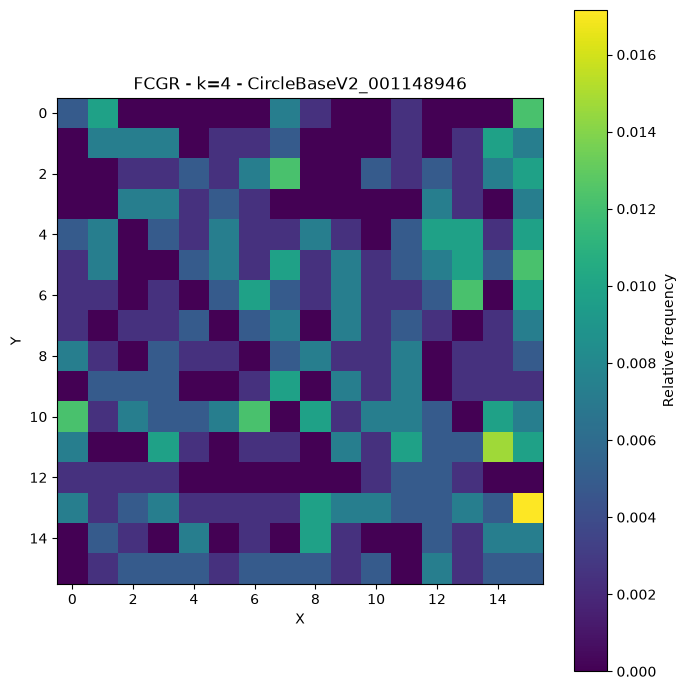

In [26]:
plt.figure(
    figsize=(7, 7)
)


plt.imshow(
    fcgr_4_norm,
    interpolation="nearest"
)


plt.title(
    f"FCGR - k=4 - {test_id}"
)


plt.xlabel("X")
plt.ylabel("Y")


plt.colorbar(
    label="Relative frequency"
)


plt.tight_layout()
plt.show()

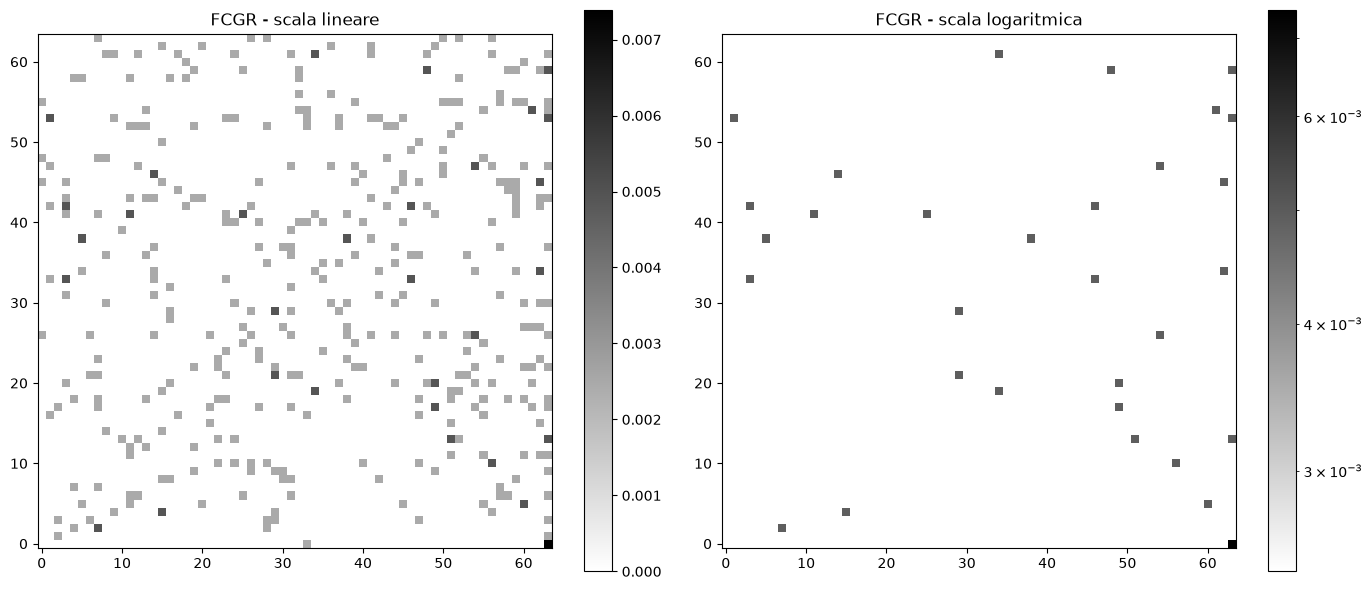

In [27]:
from matplotlib.colors import LogNorm

fcgr_counts, _, _ = compute_fcgr(
    test_sequence,
    k=6
)

fcgr_norm = normalize_fcgr(fcgr_counts)

positive_values = fcgr_norm[fcgr_norm > 0]

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

# Lineare
im1 = axes[0].imshow(
    fcgr_norm,
    cmap="gray_r",
    origin="lower",
    interpolation="nearest"
)

axes[0].set_title("FCGR - scala lineare")

plt.colorbar(
    im1,
    ax=axes[0]
)

# Logaritmica
if len(positive_values) > 0:

    im2 = axes[1].imshow(
        fcgr_norm,
        cmap="gray_r",
        origin="lower",
        interpolation="nearest",
        norm=LogNorm(
            vmin=positive_values.min(),
            vmax=positive_values.max()
        )
    )

    axes[1].set_title("FCGR - scala logaritmica")

    plt.colorbar(
        im2,
        ax=axes[1]
    )

plt.tight_layout()
plt.show()

# Analisi delle FCGR per k = 4...10

Per valutare l'effetto della dimensione del k-mer vengono analizzate
FCGR con `k` compreso tra 4 e 10.

Per ogni sequenza e per ogni valore di `k` vengono misurati:

- numero di k-mer validi;
- numero di k-mer distinti;
- numero di celle non nulle;
- occupancy della FCGR;
- sparsità della FCGR;
- correttezza della normalizzazione.

Questa analisi utilizza esclusivamente sequenze appartenenti al training set.

In [28]:
K_VALUES = list(
    range(4, 11)
)

print(
    "Valori di k analizzati:",
    K_VALUES
)


fcgr_results = []

Valori di k analizzati: [4, 5, 6, 7, 8, 9, 10]


In [29]:
for _, row in pilot_metadata.iterrows():

    seq_id = row["id"]
    disease = row["disease_clean"]

    sequence = pilot_sequences[seq_id]

    for k in K_VALUES:

        fcgr_counts, n_valid, n_distinct = (
            compute_fcgr(sequence, k)
        )

        total_cells = fcgr_counts.size

        non_zero = np.count_nonzero(
            fcgr_counts
        )

        occupancy = (
            non_zero
            / total_cells
            * 100
        )

        sparsity = 100 - occupancy

        fcgr_norm = normalize_fcgr(
            fcgr_counts
        )

        fcgr_results.append({

            "id": seq_id,

            "disease": disease,

            "k": k,

            "sequence_length": len(sequence),

            "fcgr_size": 2 ** k,

            "total_cells": total_cells,

            "valid_kmers": n_valid,

            "distinct_kmers": n_distinct,

            "non_zero_cells": non_zero,

            "occupancy_%": occupancy,

            "sparsity_%": sparsity,

            "normalized_sum": fcgr_norm.sum()
        })

In [30]:
fcgr_results = pd.DataFrame(
    fcgr_results
)

fcgr_results.head()

,id,disease,k,sequence_length,fcgr_size,total_cells,valid_kmers,distinct_kmers,non_zero_cells,occupancy_%,sparsity_%,normalized_sum
0,CircleBaseV2_001148946,gastric cancer,4,411,16,256,408,187,187,73.046875,26.953125,1.0
1,CircleBaseV2_001148946,gastric cancer,5,411,32,1024,407,315,315,30.761719,69.238281,1.0
2,CircleBaseV2_001148946,gastric cancer,6,411,64,4096,406,374,374,9.130859,90.869141,1.0
3,CircleBaseV2_001148946,gastric cancer,7,411,128,16384,405,397,397,2.423096,97.576904,1.0
4,CircleBaseV2_001148946,gastric cancer,8,411,256,65536,404,402,402,0.613403,99.386597,1.0


In [31]:
fcgr_summary = (
    fcgr_results
    .groupby("k")
    .agg({
        "fcgr_size": "first",
        "valid_kmers": "median",
        "distinct_kmers": "median",
        "non_zero_cells": "median",
        "occupancy_%": "median",
        "sparsity_%": "median",
        "normalized_sum": "median"
    })
    .reset_index()
)

fcgr_summary

,k,fcgr_size,valid_kmers,distinct_kmers,non_zero_cells,occupancy_%,sparsity_%,normalized_sum
0,4,16,395.5,176.0,176.0,68.750000,31.250000,1.0
1,5,32,394.5,288.0,288.0,28.125000,71.875000,1.0
2,6,64,393.5,346.5,346.5,8.459473,91.540527,1.0
3,7,128,392.5,373.0,373.0,2.276611,97.723389,1.0
4,8,256,391.5,380.0,380.0,0.579834,99.420166,1.0
5,9,512,390.5,383.5,383.5,0.146294,99.853706,1.0
6,10,1024,389.5,386.5,386.5,0.036860,99.963140,1.0


In [32]:
fcgr_results["normalized_sum"].describe()

count    6.300000e+02
mean     1.000000e+00
std      6.698887e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: normalized_sum, dtype: float64

Visualizzazione di una sequenza per ogni k

In [33]:
visual_id = pilot_metadata.iloc[0]["id"]

visual_sequence = pilot_sequences[
    visual_id
]

print(
    "ID:",
    visual_id
)

print(
    "Disease:",
    pilot_metadata.loc[
        pilot_metadata["id"] == visual_id,
        "disease_clean"
    ].iloc[0]
)

print(
    "Length:",
    len(visual_sequence)
)

ID: CircleBaseV2_001148946
Disease: gastric cancer
Length: 411


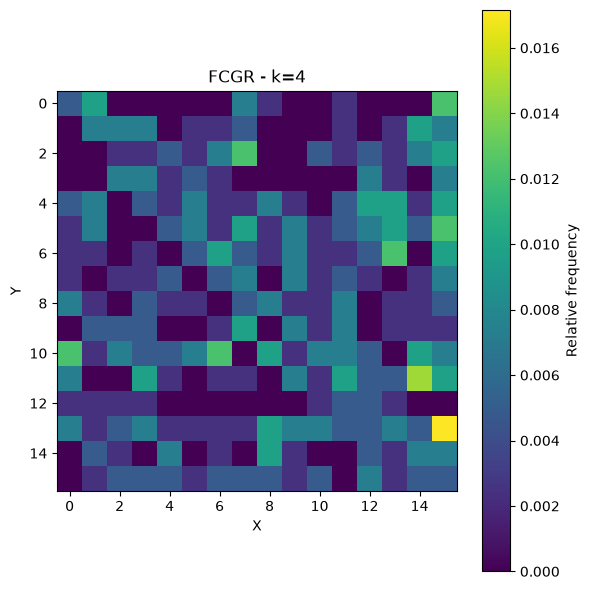

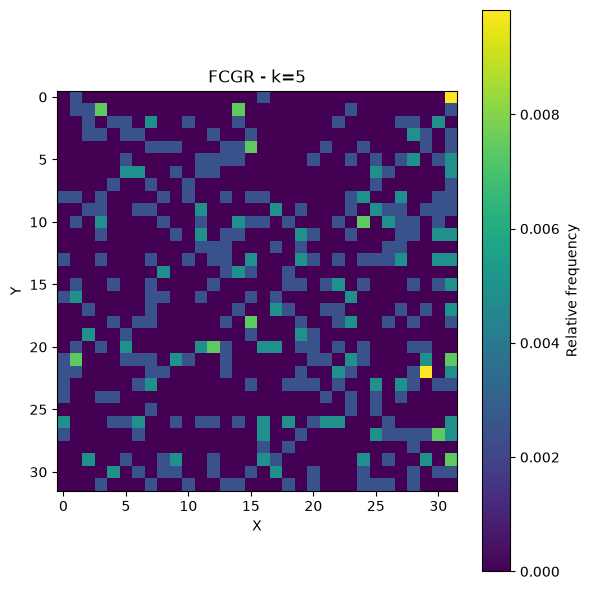

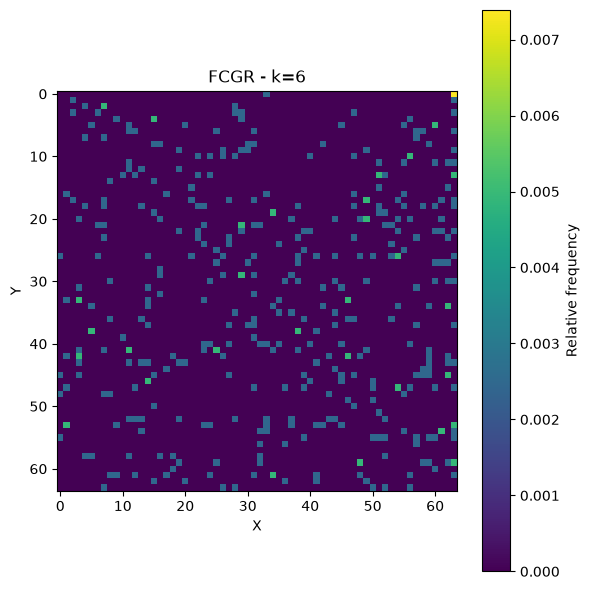

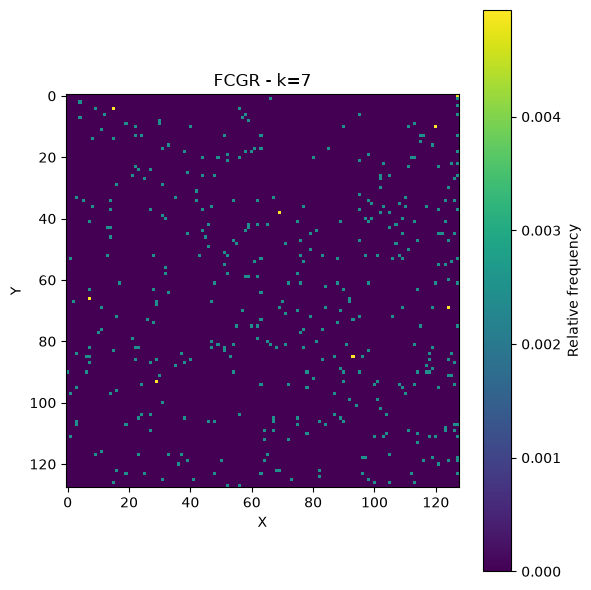

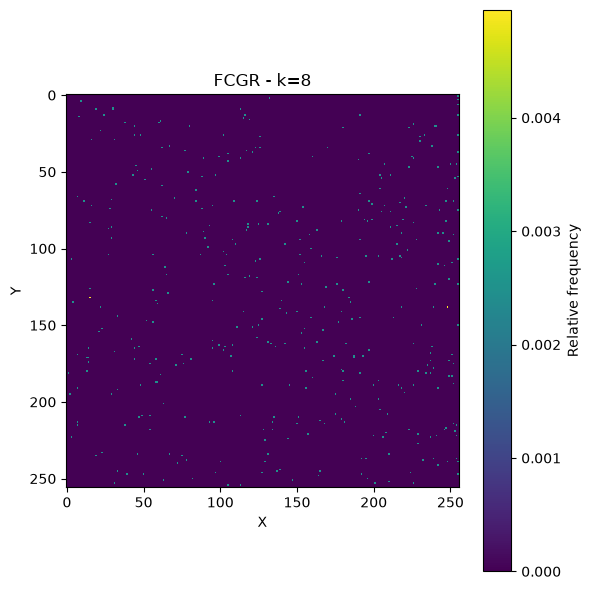

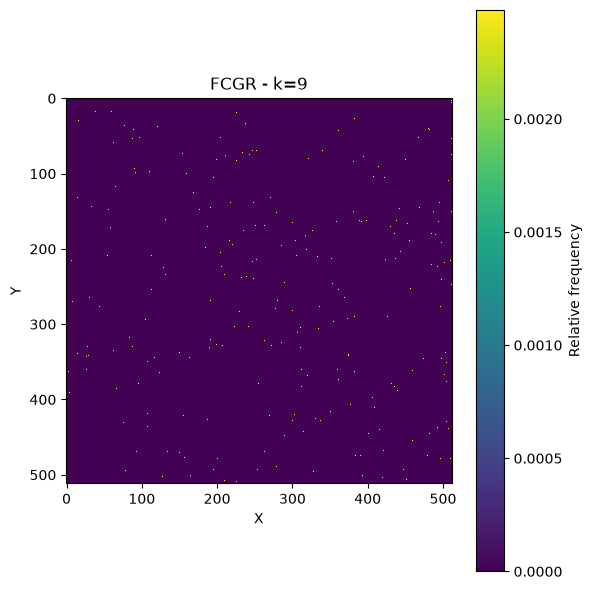

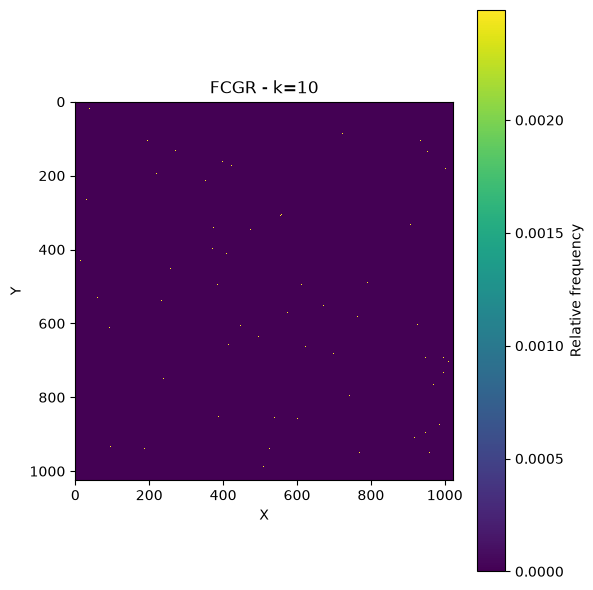

In [34]:
for k in K_VALUES:

    fcgr_counts, _, _ = compute_fcgr(
        visual_sequence,
        k
    )

    fcgr_norm = normalize_fcgr(
        fcgr_counts
    )

    plt.figure(figsize=(6, 6))

    plt.imshow(
        fcgr_norm,
        interpolation="nearest"
    )

    plt.title(
        f"FCGR - k={k}"
    )

    plt.xlabel("X")
    plt.ylabel("Y")

    plt.colorbar(
        label="Relative frequency"
    )

    plt.tight_layout()
    plt.show()

Grafico delle sparsità

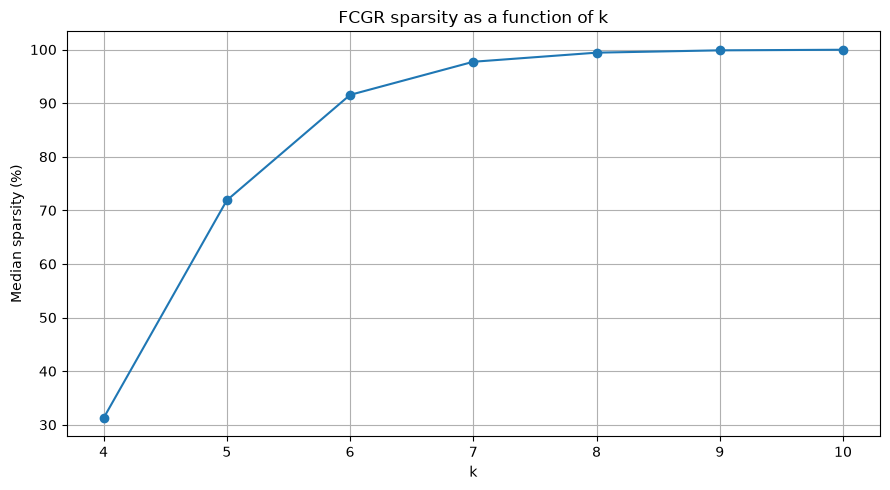

In [35]:
sparsity_by_k = (
    fcgr_results
    .groupby("k")["sparsity_%"]
    .median()
)

plt.figure(figsize=(9, 5))

plt.plot(
    sparsity_by_k.index,
    sparsity_by_k.values,
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Median sparsity (%)")
plt.title(
    "FCGR sparsity as a function of k"
)

plt.xticks(list(K_VALUES))

plt.grid(True)

plt.tight_layout()
plt.show()

Grafico dei kmer distinti

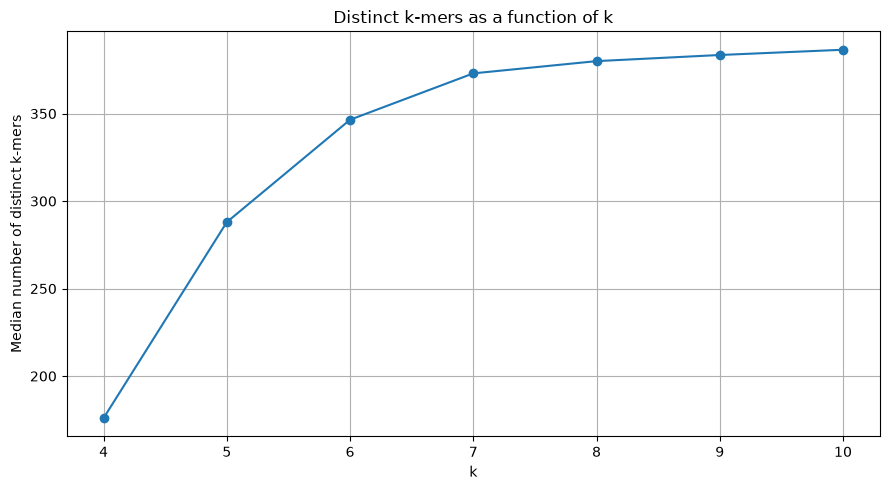

In [36]:
distinct_by_k = (
    fcgr_results
    .groupby("k")["distinct_kmers"]
    .median()
)

plt.figure(figsize=(9, 5))

plt.plot(
    distinct_by_k.index,
    distinct_by_k.values,
    marker="o"
)

plt.xlabel("k")
plt.ylabel(
    "Median number of distinct k-mers"
)

plt.title(
    "Distinct k-mers as a function of k"
)

plt.xticks(list(K_VALUES))

plt.grid(True)

plt.tight_layout()
plt.show()

Rapporto tra kmer distinti e possibili

In [37]:
occupancy_kmer = []

for k in K_VALUES:

    possible = 4 ** k

    observed = (
        fcgr_results.loc[
            fcgr_results["k"] == k,
            "distinct_kmers"
        ].median()
    )

    occupancy = (
        observed / possible * 100
    )

    occupancy_kmer.append({
        "k": k,
        "possible_kmers": possible,
        "median_distinct_kmers": observed,
        "occupancy_%": occupancy
    })

occupancy_kmer = pd.DataFrame(
    occupancy_kmer
)

occupancy_kmer

,k,possible_kmers,median_distinct_kmers,occupancy_%
0,4,256,176.0,68.750000
1,5,1024,288.0,28.125000
2,6,4096,346.5,8.459473
3,7,16384,373.0,2.276611
4,8,65536,380.0,0.579834
5,9,262144,383.5,0.146294
6,10,1048576,386.5,0.036860


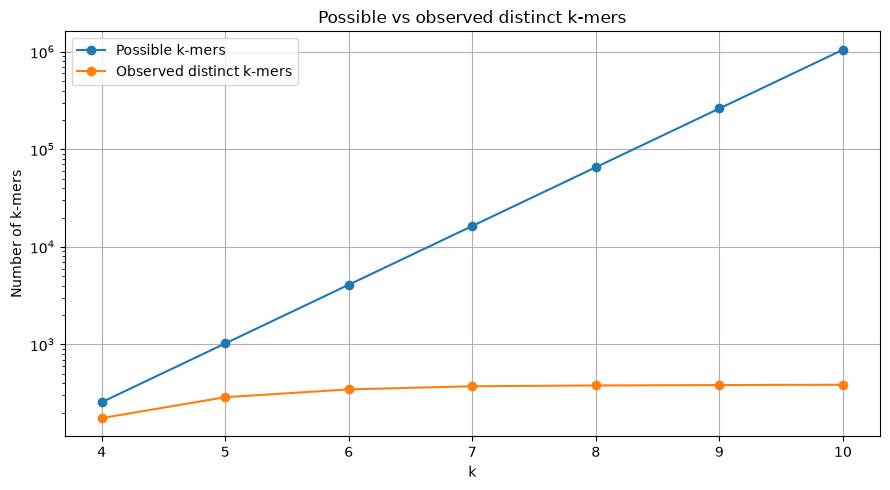

In [38]:
plt.figure(figsize=(9, 5))

plt.semilogy(
    occupancy_kmer["k"],
    occupancy_kmer["possible_kmers"],
    marker="o",
    label="Possible k-mers"
)

plt.semilogy(
    occupancy_kmer["k"],
    occupancy_kmer["median_distinct_kmers"],
    marker="o",
    label="Observed distinct k-mers"
)

plt.xlabel("k")
plt.ylabel("Number of k-mers")

plt.title(
    "Possible vs observed distinct k-mers"
)

plt.xticks(list(K_VALUES))

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

### Osservazione preliminare

La generazione delle FCGR viene verificata per tutti i valori di `k`
compresi tra 4 e 10.

All'aumentare di `k` la dimensione della matrice cresce come `2^k × 2^k`,
mentre il numero di k-mer disponibili rimane limitato dalla lunghezza
della sequenza. È quindi atteso un progressivo aumento della sparsità.

Le statistiche ottenute da questo piccolo pilot hanno principalmente
funzione di sanity check.

La scelta dei valori di `k` da utilizzare nei modelli non viene effettuata
su questo campione, ma sulla successiva analisi stratificata per classe
e lunghezza della sequenza.

# Analisi stratificata per lunghezza

Le sequenze vengono suddivise in tre fasce di lunghezza per valutare
come la sparsità della FCGR dipenda non solo da `k`, ma anche dalla
quantità di informazione disponibile nella sequenza.

In [39]:
def assign_length_bin(
    length
):

    if length < 300:
        return "short"

    elif length <= 1000:
        return "medium"

    else:
        return "long"


metadata["length_bin"] = (
    metadata["length"]
    .apply(assign_length_bin)
)


train_metadata["length_bin"] = (
    train_metadata["length"]
    .apply(assign_length_bin)
)


print(
    "Distribuzione nel manifest:"
)

display(
    metadata[
        "length_bin"
    ].value_counts()
)


print(
    "\nDistribuzione nel training set:"
)

display(
    train_metadata[
        "length_bin"
    ].value_counts()
)

Distribuzione nel manifest:


length_bin
medium    370505
long      187847
short     107329
Name: count, dtype: int64


Distribuzione nel training set:


length_bin
medium    61724
short     40332
long      24209
Name: count, dtype: int64

## Pilot statistico stratificato per classe e lunghezza

Per studiare in modo più robusto la sparsità delle FCGR viene costruito
un secondo pilot utilizzando esclusivamente il training set.

Il campionamento viene stratificato rispetto a:

- disease;
- classe di lunghezza (`short`, `medium`, `long`).

In questo modo tutte le classi dell'esperimento possono contribuire
all'analisi senza essere dominate dalle disease più numerose.

Il numero di campioni per combinazione classe/lunghezza viene mantenuto
relativamente contenuto perché per ogni sequenza devono essere generate
sette FCGR (`k=4,...,10`).

In [40]:
# PILOT_CLASSES è già stato definito
# automaticamente a partire dalle 18 classi
# presenti nel manifest.


# 18 classi × 3 fasce × 30 campioni
# produce al massimo circa 1620 sequenze,
# dimensione simile al vecchio pilot da 1500.

N_PER_CLASS_LENGTH = 30


print(
    "Classi considerate:",
    len(PILOT_CLASSES)
)

print(
    "Campioni massimi per "
    "classe/fascia:",
    N_PER_CLASS_LENGTH
)

Classi considerate: 18
Campioni massimi per classe/fascia: 30


In [41]:
pilot_parts = []


LENGTH_BINS = [
    "short",
    "medium",
    "long"
]


for class_idx, disease in enumerate(
    PILOT_CLASSES
):

    for bin_idx, length_bin in enumerate(
        LENGTH_BINS
    ):

        subset = train_metadata[
            (
                train_metadata[
                    "disease_clean"
                ]
                == disease
            )
            &
            (
                train_metadata[
                    "length_bin"
                ]
                == length_bin
            )
        ]


        if len(subset) == 0:
            continue


        sampled = subset.sample(
            n=min(
                N_PER_CLASS_LENGTH,
                len(subset)
            ),
            replace=False,
            random_state=(
                RANDOM_STATE
                + class_idx * 10
                + bin_idx
            )
        )


        pilot_parts.append(
            sampled
        )


pilot_large = pd.concat(
    pilot_parts,
    ignore_index=True
)


print(
    "Numero sequenze pilot:",
    len(pilot_large)
)


display(
    pd.crosstab(
        pilot_large[
            "disease_clean"
        ],
        pilot_large[
            "length_bin"
        ]
    )
)

Numero sequenze pilot: 1616


length_bin,long,medium,short
disease_clean,,,
branchio-oculo-facial syndrome (bofs),30,30,30
cataract,30,30,30
cervical adenocarcinoma,30,30,30
chronic kidney disease,30,30,30
colorectal cancer,30,30,30
dilated cardiomyopathy,30,30,30
gastric cancer,30,30,30
glioblastoma cancer,30,30,30
healthy,30,30,30


Recupero sequenze dal fasta

In [42]:
pilot_large_ids = pilot_large["id"].astype(str).tolist()

pilot_large_sequences = load_fasta_sequences(
    FASTA_PATH,
    pilot_large_ids
)

print("Sequenze richieste:", len(pilot_large_ids))
print("Sequenze trovate:", len(pilot_large_sequences))

Sequenze richieste: 1616
Sequenze trovate: 1616


In [43]:
missing_ids = (
    set(pilot_large_ids)
    - set(
        pilot_large_sequences.keys()
    )
)


print(
    "Sequenze mancanti:",
    len(missing_ids)
)


if missing_ids:

    print(
        "Primi ID mancanti:",
        list(missing_ids)[:10]
    )


assert len(missing_ids) == 0, (
    "Alcune sequenze del pilot "
    "non sono presenti nel FASTA."
)

Sequenze mancanti: 0


In [44]:
# K_VALUES è già stato definito precedentemente:
# [4, 5, 6, 7, 8, 9, 10]

fcgr_large_results = []

In [45]:
for _, row in pilot_large.iterrows():

    seq_id = row["id"]
    disease = row["disease_clean"]
    length_bin = row["length_bin"]

    sequence = pilot_large_sequences[seq_id]

    for k in K_VALUES:

        fcgr_counts, n_valid, n_distinct = compute_fcgr(
            sequence,
            k
        )

        total_cells = fcgr_counts.size
        non_zero = np.count_nonzero(fcgr_counts)

        occupancy = (
            non_zero / total_cells * 100
        )

        sparsity = 100 - occupancy

        if n_valid > 0:
            unique_ratio = n_distinct / n_valid
        else:
            unique_ratio = np.nan

        fcgr_large_results.append({
            "id": seq_id,
            "disease": disease,
            "length_bin": length_bin,
            "sequence_length": len(sequence),
            "k": k,
            "fcgr_size": 2 ** k,
            "valid_kmers": n_valid,
            "distinct_kmers": n_distinct,
            "unique_ratio": unique_ratio,
            "occupancy_%": occupancy,
            "sparsity_%": sparsity
        })

In [46]:
fcgr_large_results = pd.DataFrame(
    fcgr_large_results
)

fcgr_large_results.head()

,id,disease,length_bin,sequence_length,k,fcgr_size,valid_kmers,distinct_kmers,unique_ratio,occupancy_%,sparsity_%
0,CircleBaseV2_001962902,gastric cancer,short,256,4,16,253,138,0.545455,53.906250,46.093750
1,CircleBaseV2_001962902,gastric cancer,short,256,5,32,252,205,0.813492,20.019531,79.980469
2,CircleBaseV2_001962902,gastric cancer,short,256,6,64,251,232,0.924303,5.664062,94.335938
3,CircleBaseV2_001962902,gastric cancer,short,256,7,128,250,241,0.964000,1.470947,98.529053
4,CircleBaseV2_001962902,gastric cancer,short,256,8,256,249,245,0.983936,0.373840,99.626160


Analisi globale per k

In [47]:
summary_by_k = (
    fcgr_large_results
    .groupby("k")
    .agg(
        n_sequences=("id", "count"),

        median_length=("sequence_length", "median"),

        median_valid_kmers=("valid_kmers", "median"),

        median_distinct_kmers=("distinct_kmers", "median"),

        median_unique_ratio=("unique_ratio", "median"),

        median_occupancy=("occupancy_%", "median"),

        q25_occupancy=("occupancy_%", lambda x: x.quantile(0.25)),

        q75_occupancy=("occupancy_%", lambda x: x.quantile(0.75)),

        median_sparsity=("sparsity_%", "median")
    )
    .reset_index()
)

summary_by_k

,k,n_sequences,median_length,median_valid_kmers,median_distinct_kmers,median_unique_ratio,median_occupancy,q25_occupancy,q75_occupancy,median_sparsity
0,4,1616,466.0,463.0,180.0,0.364890,70.312500,51.171875,89.160156,29.687500
1,5,1616,466.0,462.0,305.0,0.675482,29.785156,18.139648,57.519531,70.214844
2,6,1616,466.0,461.0,376.0,0.860886,9.179688,5.102539,22.460938,90.820312
3,7,1616,466.0,460.0,409.0,0.943176,2.496338,1.322937,6.607056,97.503662
4,8,1616,466.0,459.0,424.0,0.977980,0.646973,0.338364,1.761627,99.353027
5,9,1616,466.0,458.0,428.0,0.991101,0.163269,0.084591,0.449848,99.836731
6,10,1616,466.0,457.0,432.0,0.996812,0.041199,0.021076,0.113845,99.958801


Analisi per fascia di lunghezza

In [48]:
summary_by_length_k = (
    fcgr_large_results
    .groupby(
        ["length_bin", "k"]
    )
    .agg(
        n=("id", "count"),
        median_length=("sequence_length", "median"),
        median_distinct=("distinct_kmers", "median"),
        median_unique_ratio=("unique_ratio", "median"),
        median_occupancy=("occupancy_%", "median"),
        median_sparsity=("sparsity_%", "median")
    )
    .reset_index()
)

summary_by_length_k

,length_bin,k,n,median_length,median_distinct,median_unique_ratio,median_occupancy,median_sparsity
0,long,4,540,1653.0,240.0,0.135331,93.750000,6.250000
1,long,5,540,1653.0,678.5,0.392872,66.259766,33.740234
2,long,6,540,1653.0,1160.0,0.691692,28.320312,71.679688
3,long,7,540,1653.0,1421.5,0.870390,8.676147,91.323853
4,long,8,540,1653.0,1520.0,0.944367,2.319336,97.680664
5,long,9,540,1653.0,1572.5,0.972205,0.599861,99.400139
6,long,10,540,1653.0,1594.0,0.985040,0.152016,99.847984
7,medium,4,540,463.0,181.0,0.384313,70.703125,29.296875
8,medium,5,540,463.0,311.0,0.694085,30.371094,69.628906
9,medium,6,540,463.0,391.0,0.881497,9.545898,90.454102


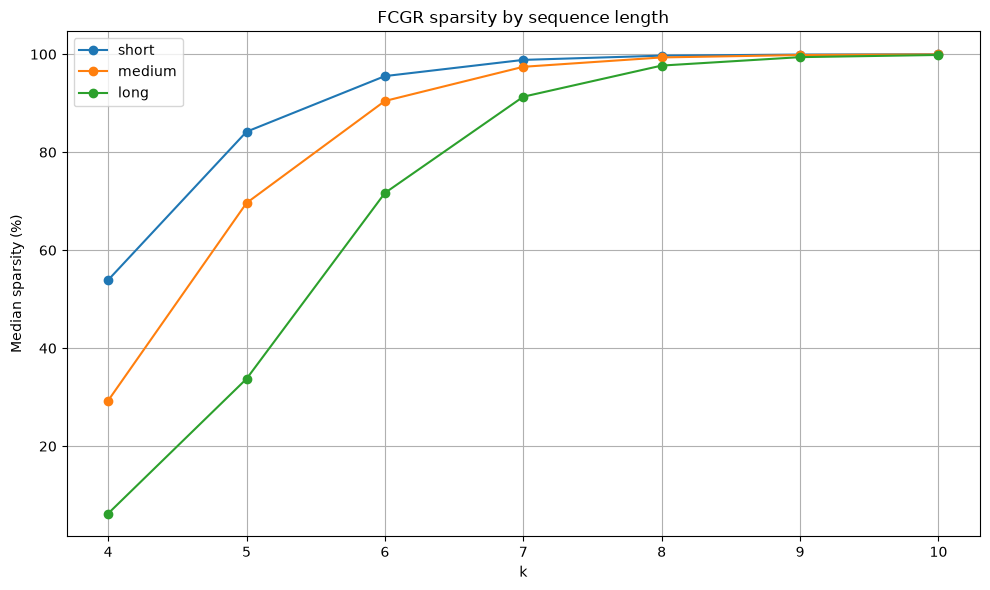

In [49]:
plt.figure(figsize=(10, 6))

for length_bin in ["short", "medium", "long"]:

    subset = summary_by_length_k[
        summary_by_length_k["length_bin"]
        == length_bin
    ]

    plt.plot(
        subset["k"],
        subset["median_sparsity"],
        marker="o",
        label=length_bin
    )

plt.xlabel("k")
plt.ylabel("Median sparsity (%)")
plt.title("FCGR sparsity by sequence length")
plt.xticks(list(K_VALUES))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Grafico unique ratio

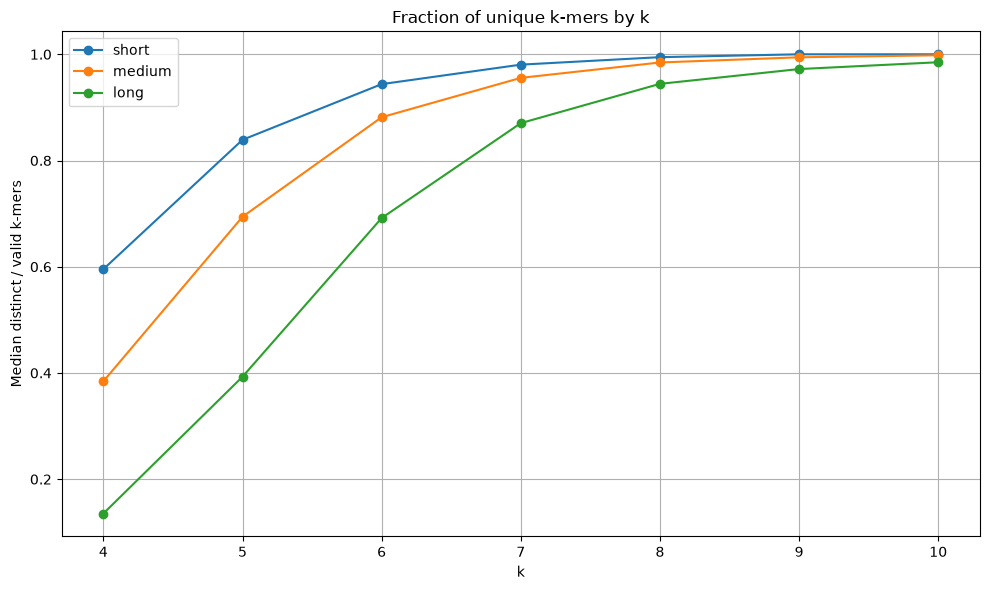

In [50]:
plt.figure(figsize=(10, 6))

for length_bin in ["short", "medium", "long"]:

    subset = summary_by_length_k[
        summary_by_length_k["length_bin"]
        == length_bin
    ]

    plt.plot(
        subset["k"],
        subset["median_unique_ratio"],
        marker="o",
        label=length_bin
    )

plt.xlabel("k")
plt.ylabel("Median distinct / valid k-mers")
plt.title("Fraction of unique k-mers by k")
plt.xticks(list(K_VALUES))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Boxplot della sparsità

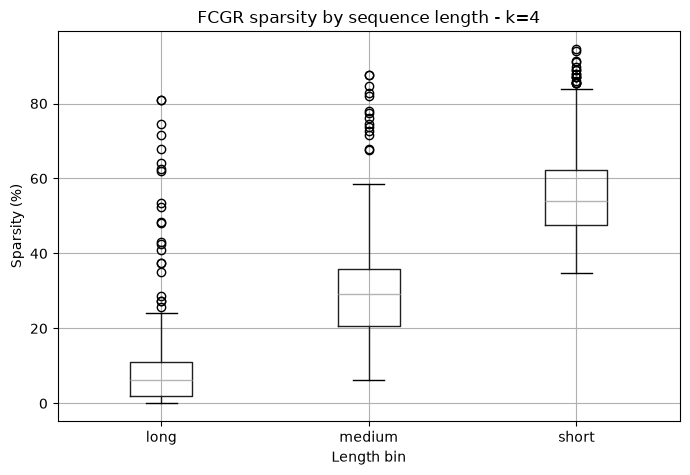

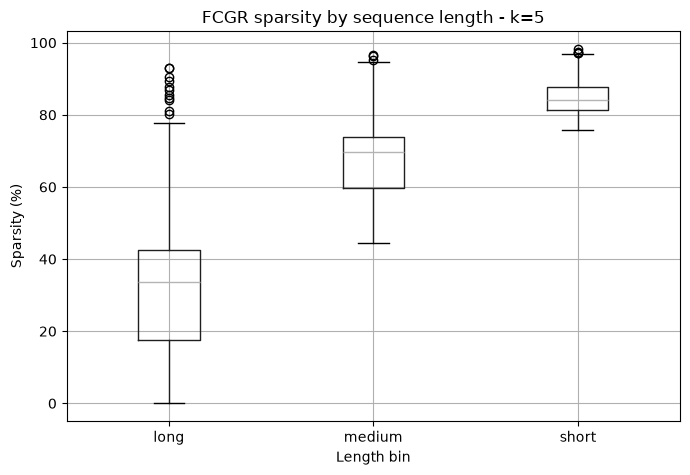

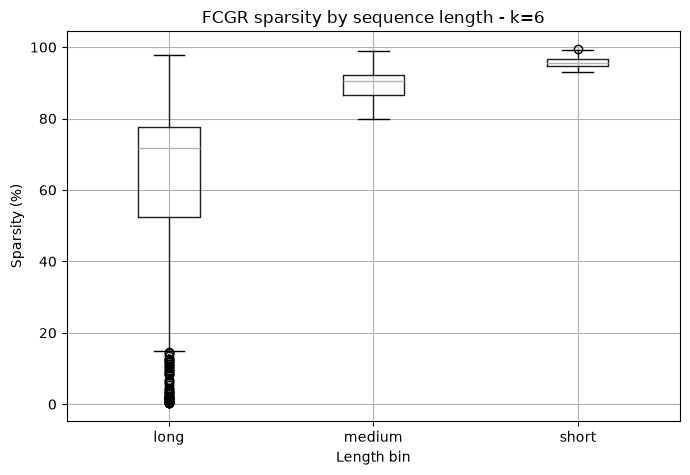

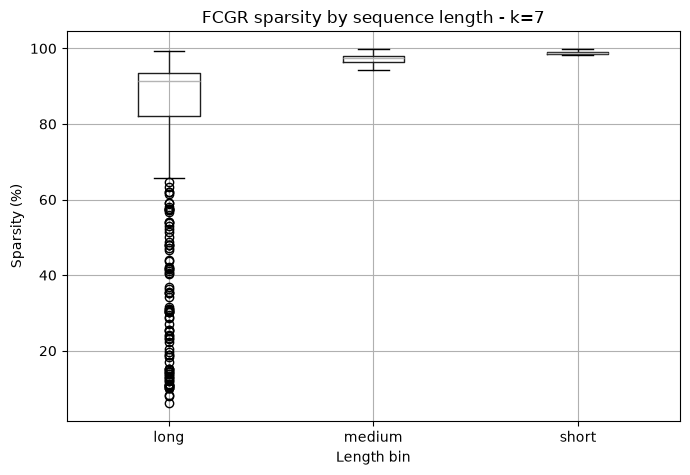

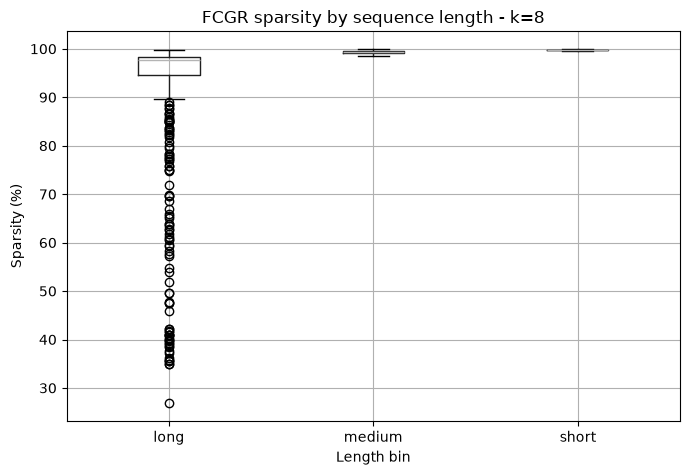

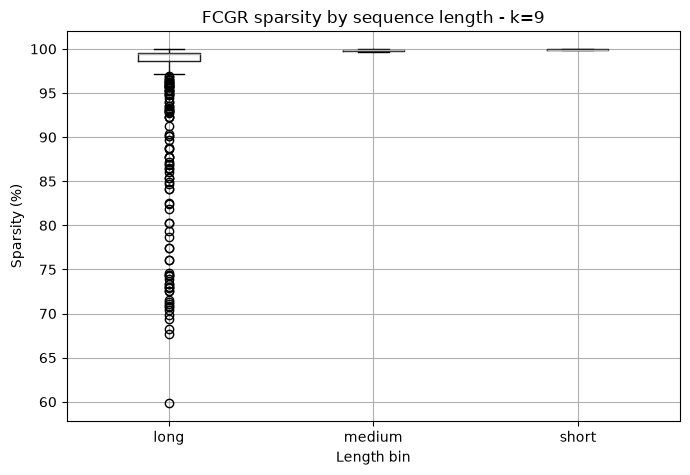

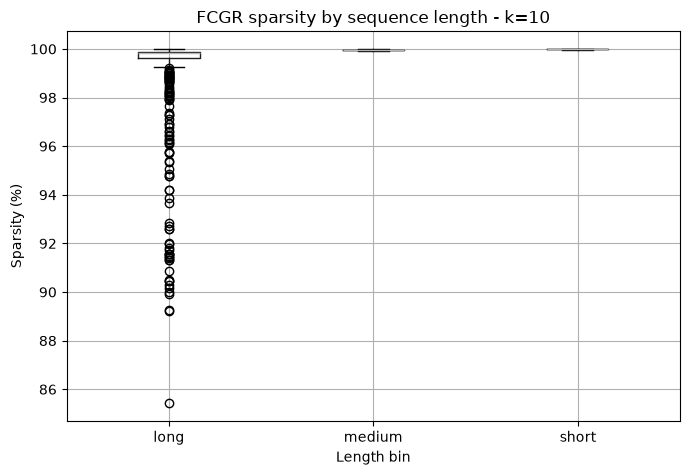

In [51]:
for k in K_VALUES:

    data_k = fcgr_large_results[
        fcgr_large_results["k"] == k
    ]

    data_k.boxplot(
        column="sparsity_%",
        by="length_bin",
        figsize=(7, 5)
    )

    plt.title(
        f"FCGR sparsity by sequence length - k={k}"
    )

    plt.suptitle("")
    plt.xlabel("Length bin")
    plt.ylabel("Sparsity (%)")

    plt.tight_layout()
    plt.show()

Memoria teorica

In [52]:
memory_rows = []


n_train_samples = (
    metadata[
        "split_cluster"
    ] == "train"
).sum()


n_manifest_samples = len(
    metadata
)


for k in K_VALUES:

    size = 2 ** k

    cells = (
        size
        * size
    )

    bytes_float32 = (
        cells
        * 4
    )


    memory_per_sample_mb = (
        bytes_float32
        / (1024 ** 2)
    )


    train_memory_gb = (
        bytes_float32
        * n_train_samples
        / (1024 ** 3)
    )


    full_memory_gb = (
        bytes_float32
        * n_manifest_samples
        / (1024 ** 3)
    )


    memory_rows.append({

        "k": k,

        "fcgr_shape":
            f"{size}x{size}",

        "cells":
            cells,

        "memory_float32_MB":
            memory_per_sample_mb,

        "train_dense_float32_GB":
            train_memory_gb,

        "full_manifest_dense_float32_GB":
            full_memory_gb
    })


memory_by_k = pd.DataFrame(
    memory_rows
)


memory_by_k

,k,fcgr_shape,cells,memory_float32_MB,train_dense_float32_GB,full_manifest_dense_float32_GB
0,4,16x16,256,0.000977,0.120416,0.634843
1,5,32x32,1024,0.003906,0.481663,2.539371
2,6,64x64,4096,0.015625,1.926651,10.157486
3,7,128x128,16384,0.062500,7.706604,40.629944
4,8,256x256,65536,0.250000,30.826416,162.519775
5,9,512x512,262144,1.000000,123.305664,650.079102
6,10,1024x1024,1048576,4.000000,493.222656,2600.316406


Verifica sparsità per disease

In [53]:
summary_by_disease_k = (
    fcgr_large_results
    .groupby(
        ["disease", "k"]
    )
    .agg(
        median_length=("sequence_length", "median"),
        median_sparsity=("sparsity_%", "median"),
        median_unique_ratio=("unique_ratio", "median")
    )
    .reset_index()
)

summary_by_disease_k

,disease,k,median_length,median_sparsity,median_unique_ratio
0,branchio-oculo-facial syndrome (bofs),4,443.0,30.078125,0.393942
1,branchio-oculo-facial syndrome (bofs),5,443.0,68.652344,0.705772
2,branchio-oculo-facial syndrome (bofs),6,443.0,90.258789,0.877750
3,branchio-oculo-facial syndrome (bofs),7,443.0,97.399902,0.952988
4,branchio-oculo-facial syndrome (bofs),8,443.0,99.339294,0.983054
...,...,...,...,...,...
121,prostate cancer,6,445.0,91.027832,0.866739
122,prostate cancer,7,445.0,97.558594,0.948272
123,prostate cancer,8,445.0,99.375153,0.978101
124,prostate cancer,9,445.0,99.842834,0.991380


Tabella finale sintetica

In [54]:
final_k_summary = (
    summary_by_k.merge(
        memory_by_k[
            [
                "k",
                "fcgr_shape",
                "memory_float32_MB",
                "train_dense_float32_GB",
                "full_manifest_dense_float32_GB"
            ]
        ],
        on="k",
        how="left"
    )
)


final_k_summary = (
    final_k_summary[
        [
            "k",
            "fcgr_shape",
            "median_distinct_kmers",
            "median_unique_ratio",
            "median_occupancy",
            "median_sparsity",
            "memory_float32_MB",
            "train_dense_float32_GB",
            "full_manifest_dense_float32_GB"
        ]
    ]
)


final_k_summary

,k,fcgr_shape,median_distinct_kmers,median_unique_ratio,median_occupancy,median_sparsity,memory_float32_MB,train_dense_float32_GB,full_manifest_dense_float32_GB
0,4,16x16,180.0,0.364890,70.312500,29.687500,0.000977,0.120416,0.634843
1,5,32x32,305.0,0.675482,29.785156,70.214844,0.003906,0.481663,2.539371
2,6,64x64,376.0,0.860886,9.179688,90.820312,0.015625,1.926651,10.157486
3,7,128x128,409.0,0.943176,2.496338,97.503662,0.062500,7.706604,40.629944
4,8,256x256,424.0,0.977980,0.646973,99.353027,0.250000,30.826416,162.519775
5,9,512x512,428.0,0.991101,0.163269,99.836731,1.000000,123.305664,650.079102
6,10,1024x1024,432.0,0.996812,0.041199,99.958801,4.000000,493.222656,2600.316406


## Selezione dei valori di k per gli esperimenti Siamese

L'analisi mostra un chiaro compromesso tra risoluzione della FCGR,
sparsità e costo computazionale.

`k=4` produce matrici molto dense, soprattutto per le sequenze lunghe,
indicando una possibile saturazione dello spazio dei possibili k-mer.

`k=5` mantiene una occupancy relativamente elevata e un costo
computazionale molto ridotto.

`k=6` rappresenta un compromesso tra risoluzione, sparsità e numero
di k-mer distinti e viene quindi scelto come valore principale per
la prima implementazione end-to-end della Siamese Network.

`k=7` presenta una sparsità maggiore, ma viene mantenuto come valore
sperimentale per verificare se una maggiore risoluzione della
rappresentazione migliori la separazione dello spazio latente.

Per `k >= 8` le FCGR diventano estremamente sparse, con occupancy
mediana inferiore all'1%, mentre il costo in memoria cresce rapidamente.

Per gli esperimenti successivi vengono quindi selezionati:

- k = 5
- k = 6
- k = 7

La prima pipeline Siamese verrà implementata utilizzando k = 6.

In [55]:
SELECTED_K_VALUES = [
    5,
    6,
    7
]

DEFAULT_K = 6

print(
    "k selezionati per gli esperimenti:",
    SELECTED_K_VALUES
)

print(
    "k utilizzato per la prima pipeline:",
    DEFAULT_K
)

k selezionati per gli esperimenti: [5, 6, 7]
k utilizzato per la prima pipeline: 6


Salvataggio risultati

In [56]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "fcgr_analysis"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Results directory:")
print(RESULTS_DIR)

Results directory:
..\results\fcgr_analysis


In [57]:
summary_by_k.to_csv(
    RESULTS_DIR
    / "summary_by_k.csv",
    index=False
)


summary_by_length_k.to_csv(
    RESULTS_DIR
    / "summary_by_length_k.csv",
    index=False
)


summary_by_disease_k.to_csv(
    RESULTS_DIR
    / "summary_by_disease_k.csv",
    index=False
)


memory_by_k.to_csv(
    RESULTS_DIR
    / "memory_by_k.csv",
    index=False
)


final_k_summary.to_csv(
    RESULTS_DIR
    / "final_k_summary.csv",
    index=False
)


print(
    "FCGR analysis results saved."
)

FCGR analysis results saved.


In [58]:
fcgr_large_results.to_csv(
    RESULTS_DIR / "fcgr_pilot_results.csv",
    index=False
)

# Conclusioni della fase 2 — Analisi delle FCGR

In questa fase è stata implementata e verificata la generazione delle
Frequency Chaos Game Representations (FCGR) a partire dalle sequenze eccDNA
selezionate nel manifest prodotto dal notebook precedente.

Il notebook utilizza `siamese_primary_manifest.tsv`, che contiene le classi
selezionate per l'esperimento Siamese e il training set già sottoposto a
downsampling.

## Separazione degli split

L'analisi utilizzata per studiare la rappresentazione FCGR e scegliere i valori
di `k` viene effettuata esclusivamente sul training set.

Validation e test non vengono utilizzati nella scelta della rappresentazione,
in modo da mantenere indipendenti gli insiemi destinati alla valutazione del
modello.

## Validazione FASTA

Le sequenze vengono recuperate dal FASTA attraverso l'identificativo `id`.
Sul pilot vengono controllati:

- presenza della sequenza nel FASTA;
- lunghezza della sequenza;
- presenza di basi non canoniche;
- coerenza tra lunghezza riportata nei metadati e lunghezza effettiva.

I k-mer contenenti caratteri diversi da A, C, G e T vengono ignorati durante
la costruzione della FCGR.

## Analisi dei k-mer

Le FCGR vengono analizzate per valori di `k` compresi tra 4 e 10.

Per ogni rappresentazione vengono misurati:

- numero di k-mer validi;
- numero di k-mer distinti;
- unique ratio;
- occupancy;
- sparsità;
- dimensione della matrice;
- costo teorico in memoria.

L'analisi viene effettuata inizialmente su un piccolo pilot tecnico e
successivamente su un pilot più ampio stratificato rispetto alla disease
e alla lunghezza della sequenza.

Il pilot statistico include tutte le classi dell'esperimento ed è costruito
esclusivamente utilizzando campioni del training set.

## Memoria

La dimensione di una FCGR cresce esponenzialmente con `k`, poiché una matrice
FCGR ha dimensione `2^k × 2^k`.

Oltre al costo della singola matrice viene quindi stimata anche la memoria
teorica necessaria per rappresentare in formato `float32` l'intero training
set e l'intero manifest.

Questa analisi è necessaria per evitare di generare e memorizzare
indiscriminatamente matrici dense molto grandi, in particolare per valori
elevati di `k`.

## Selezione dei valori di k

L'analisi di sparsità, occupancy, unique ratio, lunghezza delle sequenze
e costo in memoria ha permesso di selezionare tre valori da utilizzare
negli esperimenti successivi:

- `k=5`
- `k=6`
- `k=7`

`k=6` viene scelto come configurazione iniziale per la costruzione
della pipeline Siamese end-to-end.

`k=5` e `k=7` verranno successivamente utilizzati nell'ablation study
per valutare l'effetto della dimensione del k-mer sulle performance
del modello.

I valori `k=8`, `k=9` e `k=10` sono stati analizzati come richiesto,
ma non vengono utilizzati inizialmente nel training a causa dell'elevata
sparsità e del maggiore costo computazionale.

## Fase successiva

Dopo la selezione dei valori di `k`, la fase successiva sarà dedicata alla
preparazione dell'input per la Siamese Network.

Poiché gli stessi sample possono essere utilizzati in molte coppie differenti,
non verranno generate tutte le possibili combinazioni in anticipo.

Verrà invece progettato un `PairDataset` PyTorch capace di campionare
dinamicamente coppie positive e negative all'interno di ciascuno split,
utilizzando un unico CNN encoder con pesi condivisi.

Prima del training verrà inoltre definita una strategia efficiente per il
calcolo e/o il caching delle FCGR selezionate, evitando di ricalcolare
inutilmente la stessa rappresentazione ogni volta che un sample viene
utilizzato in una coppia.

In [60]:
fcgr_log = np.log1p(fcgr_norm)

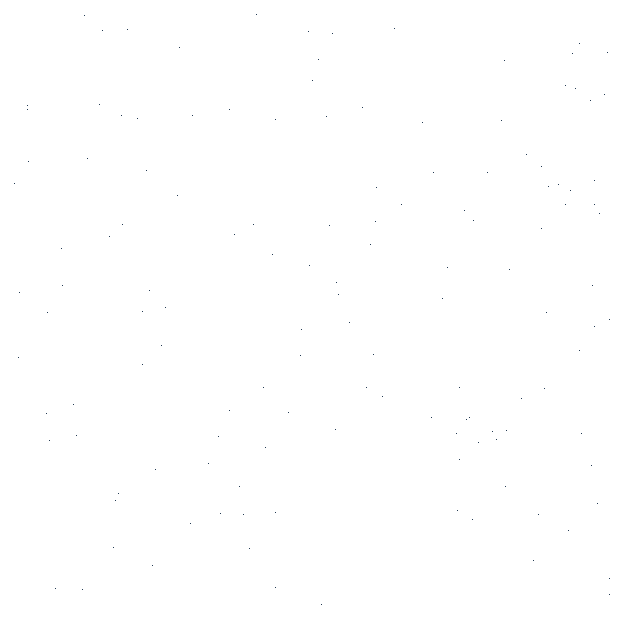

: 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

slide_cmap = LinearSegmentedColormap.from_list(
    "slide_fcgr",
    [
        "#FFFFFF",
        "#DDE8EF",
        "#9FB7C8",
        "#536F86",
        "#243B53"
    ]
)

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(
    fcgr_log,
    cmap=slide_cmap,
    interpolation="nearest",
    origin="lower"
)

ax.axis("off")

plt.tight_layout(pad=0)

plt.savefig(
    "fcgr_slide_blue.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0,
    transparent=True
)

plt.show()